In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import os
import re
from pyproj import Transformer
from scipy.spatial import cKDTree
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import root
import netCDF4 as nc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import random

from grafi import (
    display_error_tables,
    display_winddir_met,
    display_cosine,
    plot_metric_res_2,
    plot_metric_res,
    plot_wind_comparison,
    plot_wind_speed_error_by_hour_multistation,
    plot_wind_speed_error_by_month_all_stations,
    plot_wind_errors_all_stations,
    plot_wdir_error_by_wspeed_all_stations,
    plot_absolute_wind_speed_error_windrose,
    compare_wind_plots_for_stations,
    plot_wind_speed_error_windrose,
    plot_absolute_wind_direction_error_windrose,
    plot_wind_direction_error_windrose,
    plot_wind_speed_comparison
)
from utils import (
    finalize_df,
    evaluate_model,
    prepare_observations,
    get_model_stations_data,
)
from postaje import (
    get_stations, get_names
)

In [2]:
base_path = "C:\\Users\\alex\\Desktop\\veter_data"

if not os.path.exists(base_path):
    print(f"{base_path} ne obstaja")

In [3]:
# meteopgt2021.all
file_2021 = os.path.join(base_path, 'meteopgt2021.all')
meteopgt_2021 = prepare_observations(file_2021, 2021)

# meteopgt2023.all
file_2023 = os.path.join(base_path, 'meteopgt2023.all')
meteopgt_2023 = prepare_observations(file_2023, 2023)

In [4]:
sns.set_theme(context='notebook', style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

In [5]:
base_path_250_2021 = os.path.join(base_path, "VeterPodatkiARSO", "WND_ASCII_TEST")
if not os.path.exists(base_path_250_2021):
    print(f"{base_path_250_2021}' ne obstja")
stations = get_stations()
stations = get_model_stations_data(base_path_250_2021, stations, "025km_2021")
df_2021 = finalize_df(meteopgt_2021, stations)
results_2021 = evaluate_model(stations, df_2021)


base_path_250_2023 = os.path.join(base_path, "VeterPodatkiARSO", "WND_ASCII")
if not os.path.exists(base_path_250_2023):
    print(f"{base_path_250_2023}' ne obstja")
stations = get_stations()
stations = get_model_stations_data(base_path_250_2023, stations, "025km_2023")
df_2023 = finalize_df(meteopgt_2023, stations)
results_2023 = evaluate_model(stations, df_2023)    


base_path_250_2021_new = os.path.join(base_path, "VeterPodatkiARSO", "WND_ASCII_new")
if not os.path.exists(base_path_250_2021_new):
    print(f"{base_path_250_2021_new}' ne obstja")
stations = get_stations()
stations = get_model_stations_data(base_path_250_2021_new, stations, "025km_2021_new")
df_2021_2 = finalize_df(meteopgt_2021, stations)
results_2021_2 = evaluate_model(stations, df_2021_2)

loaded
loaded
loaded


In [6]:
names = get_names()

df_both = pd.concat([df_2021, df_2023])
# df_both = df_2023
results_both = evaluate_model(get_stations(), df_both)
print(results_both)

               Name      MAE    RMSE    MAPE  Cosine      R2    Bias
0        bezigrad_u   0.6614  1.1451   72.43  0.4818  0.2167  0.0417
1        bezigrad_v   0.5629  0.9942   72.42  0.4818  0.1631  0.0564
2   bezigrad_WSpeed   0.5628  0.9484   45.30     NaN  0.3098 -0.0386
3     bezigrad_WDir  50.1924     NaN     NaN     NaN     NaN -1.9446
4           borst_u   1.0205  1.5031  125.00  0.1112 -0.5699 -0.0886
5           borst_v   0.9950  1.4366  111.34  0.1112 -0.5159 -0.0504
6      borst_WSpeed   0.7736  1.2919   68.58     NaN -0.4147 -0.1495
7        borst_WDir  81.9086     NaN     NaN     NaN     NaN  3.3674
8          let_lj_u   0.8819  1.5313   74.72  0.5294  0.1665 -0.0236
9          let_lj_v   0.5910  1.0336   68.84  0.5294  0.1838  0.0510
10    let_lj_WSpeed   0.6465  1.1162   46.97     NaN  0.2537 -0.1670
11      let_lj_WDir  46.4463     NaN     NaN     NaN     NaN -0.5815
12          pasja_u   1.0982  1.3737   98.70  0.3043  0.0747  0.1129
13          pasja_v   0.9459  1.22

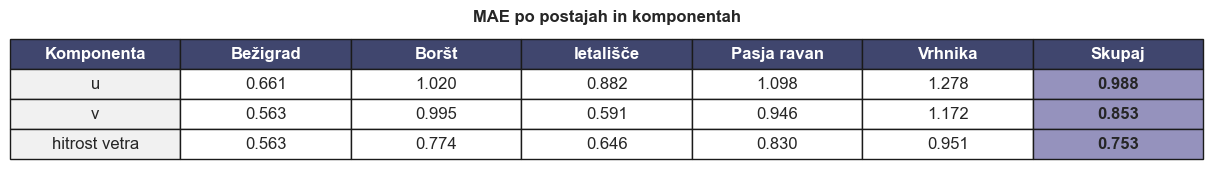

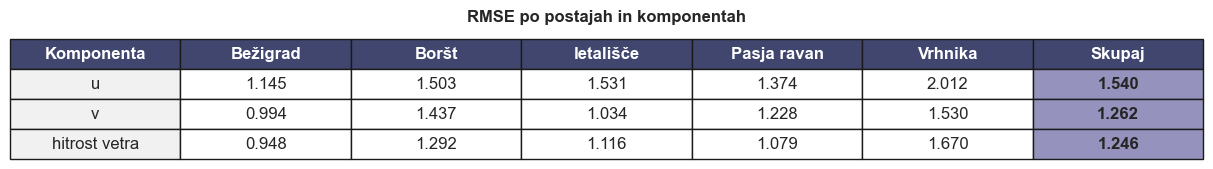

In [7]:
display_error_tables(results_both, stations, n=names)

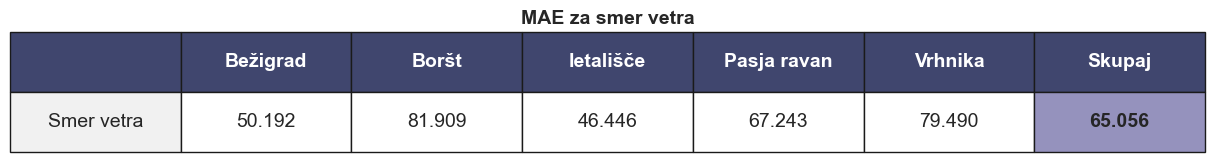

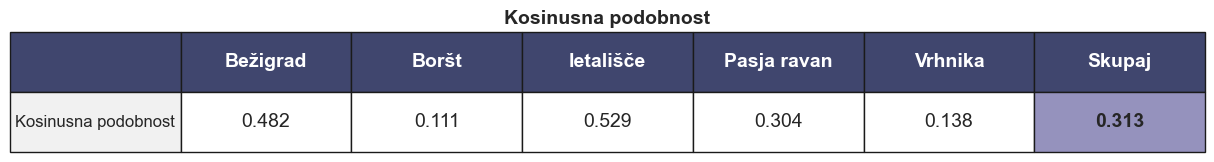

In [8]:
display_winddir_met(results_both, stations, names)
display_cosine(results_both, stations, names)

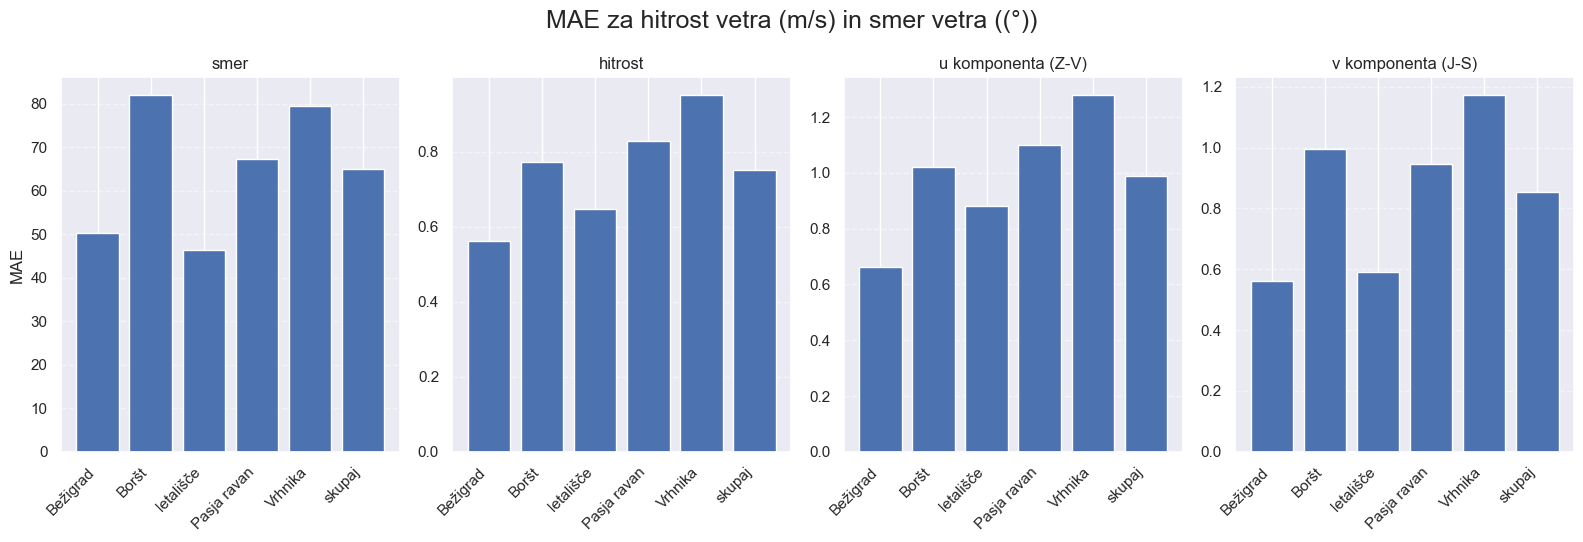

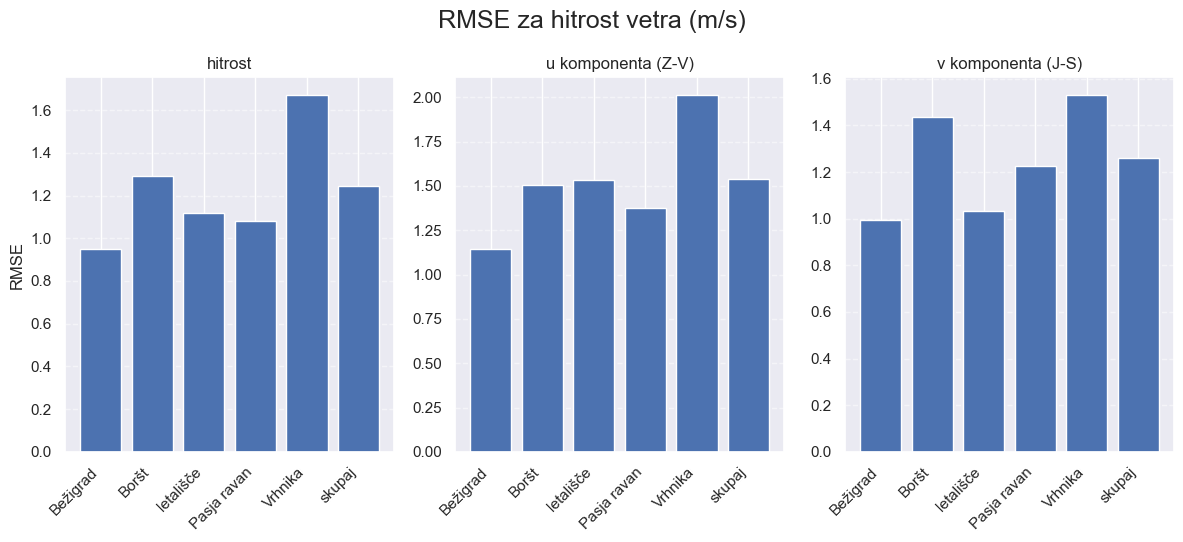

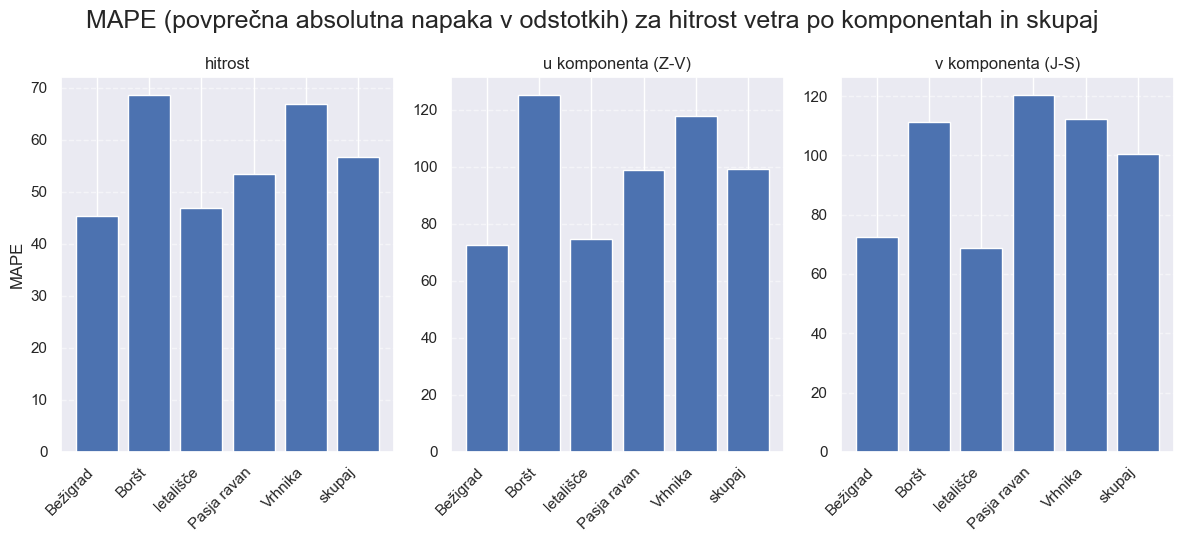

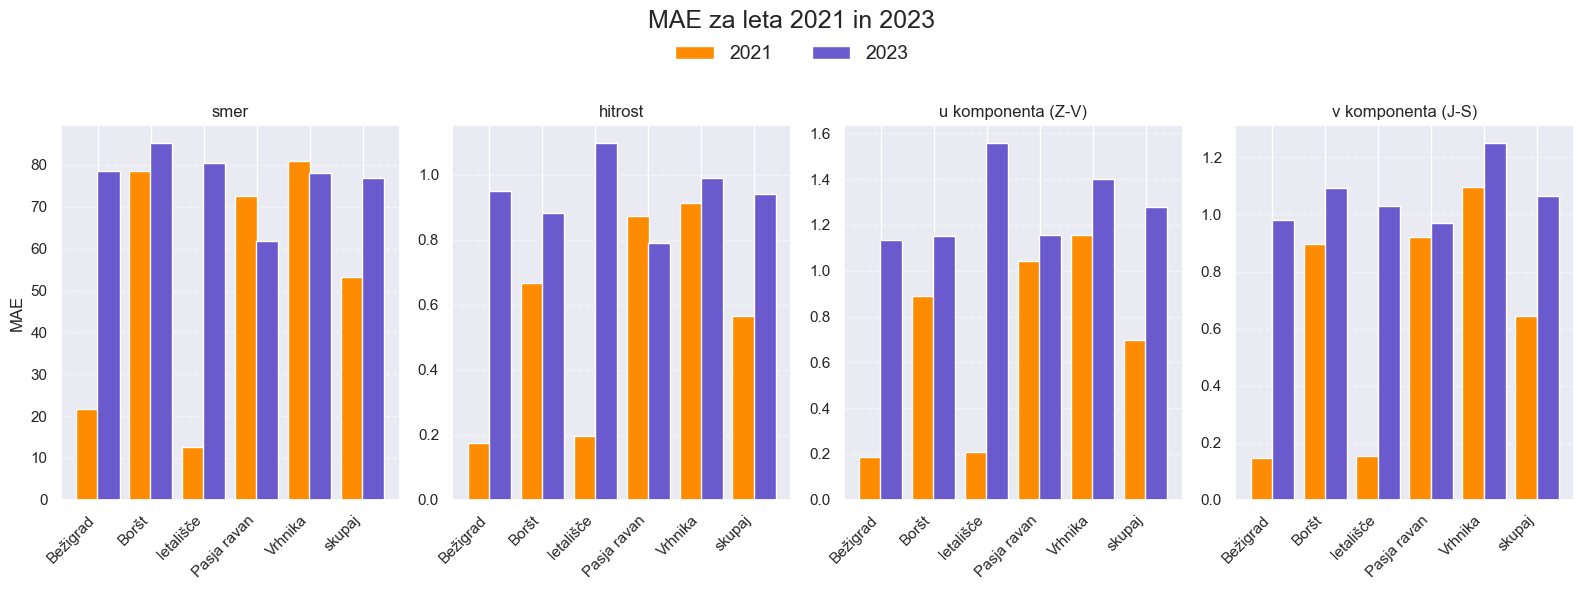

In [9]:
plot_metric_res(metric='MAE', df1=results_both, names=names, title='MAE za hitrost vetra (m/s) in smer vetra ((°))')

plot_metric_res(metric='RMSE', df1=results_both, names=names, title='RMSE za hitrost vetra (m/s)', ign=["WDir"])

plot_metric_res(metric='MAPE', df1=results_both, names=names, title='MAPE (povprečna absolutna napaka v odstotkih) za hitrost vetra po komponentah in skupaj', ign=["WDir"])

plot_metric_res_2(metric='MAE', df1=results_2021, df2=results_2023, names=names, title='MAE za leta 2021 in 2023')

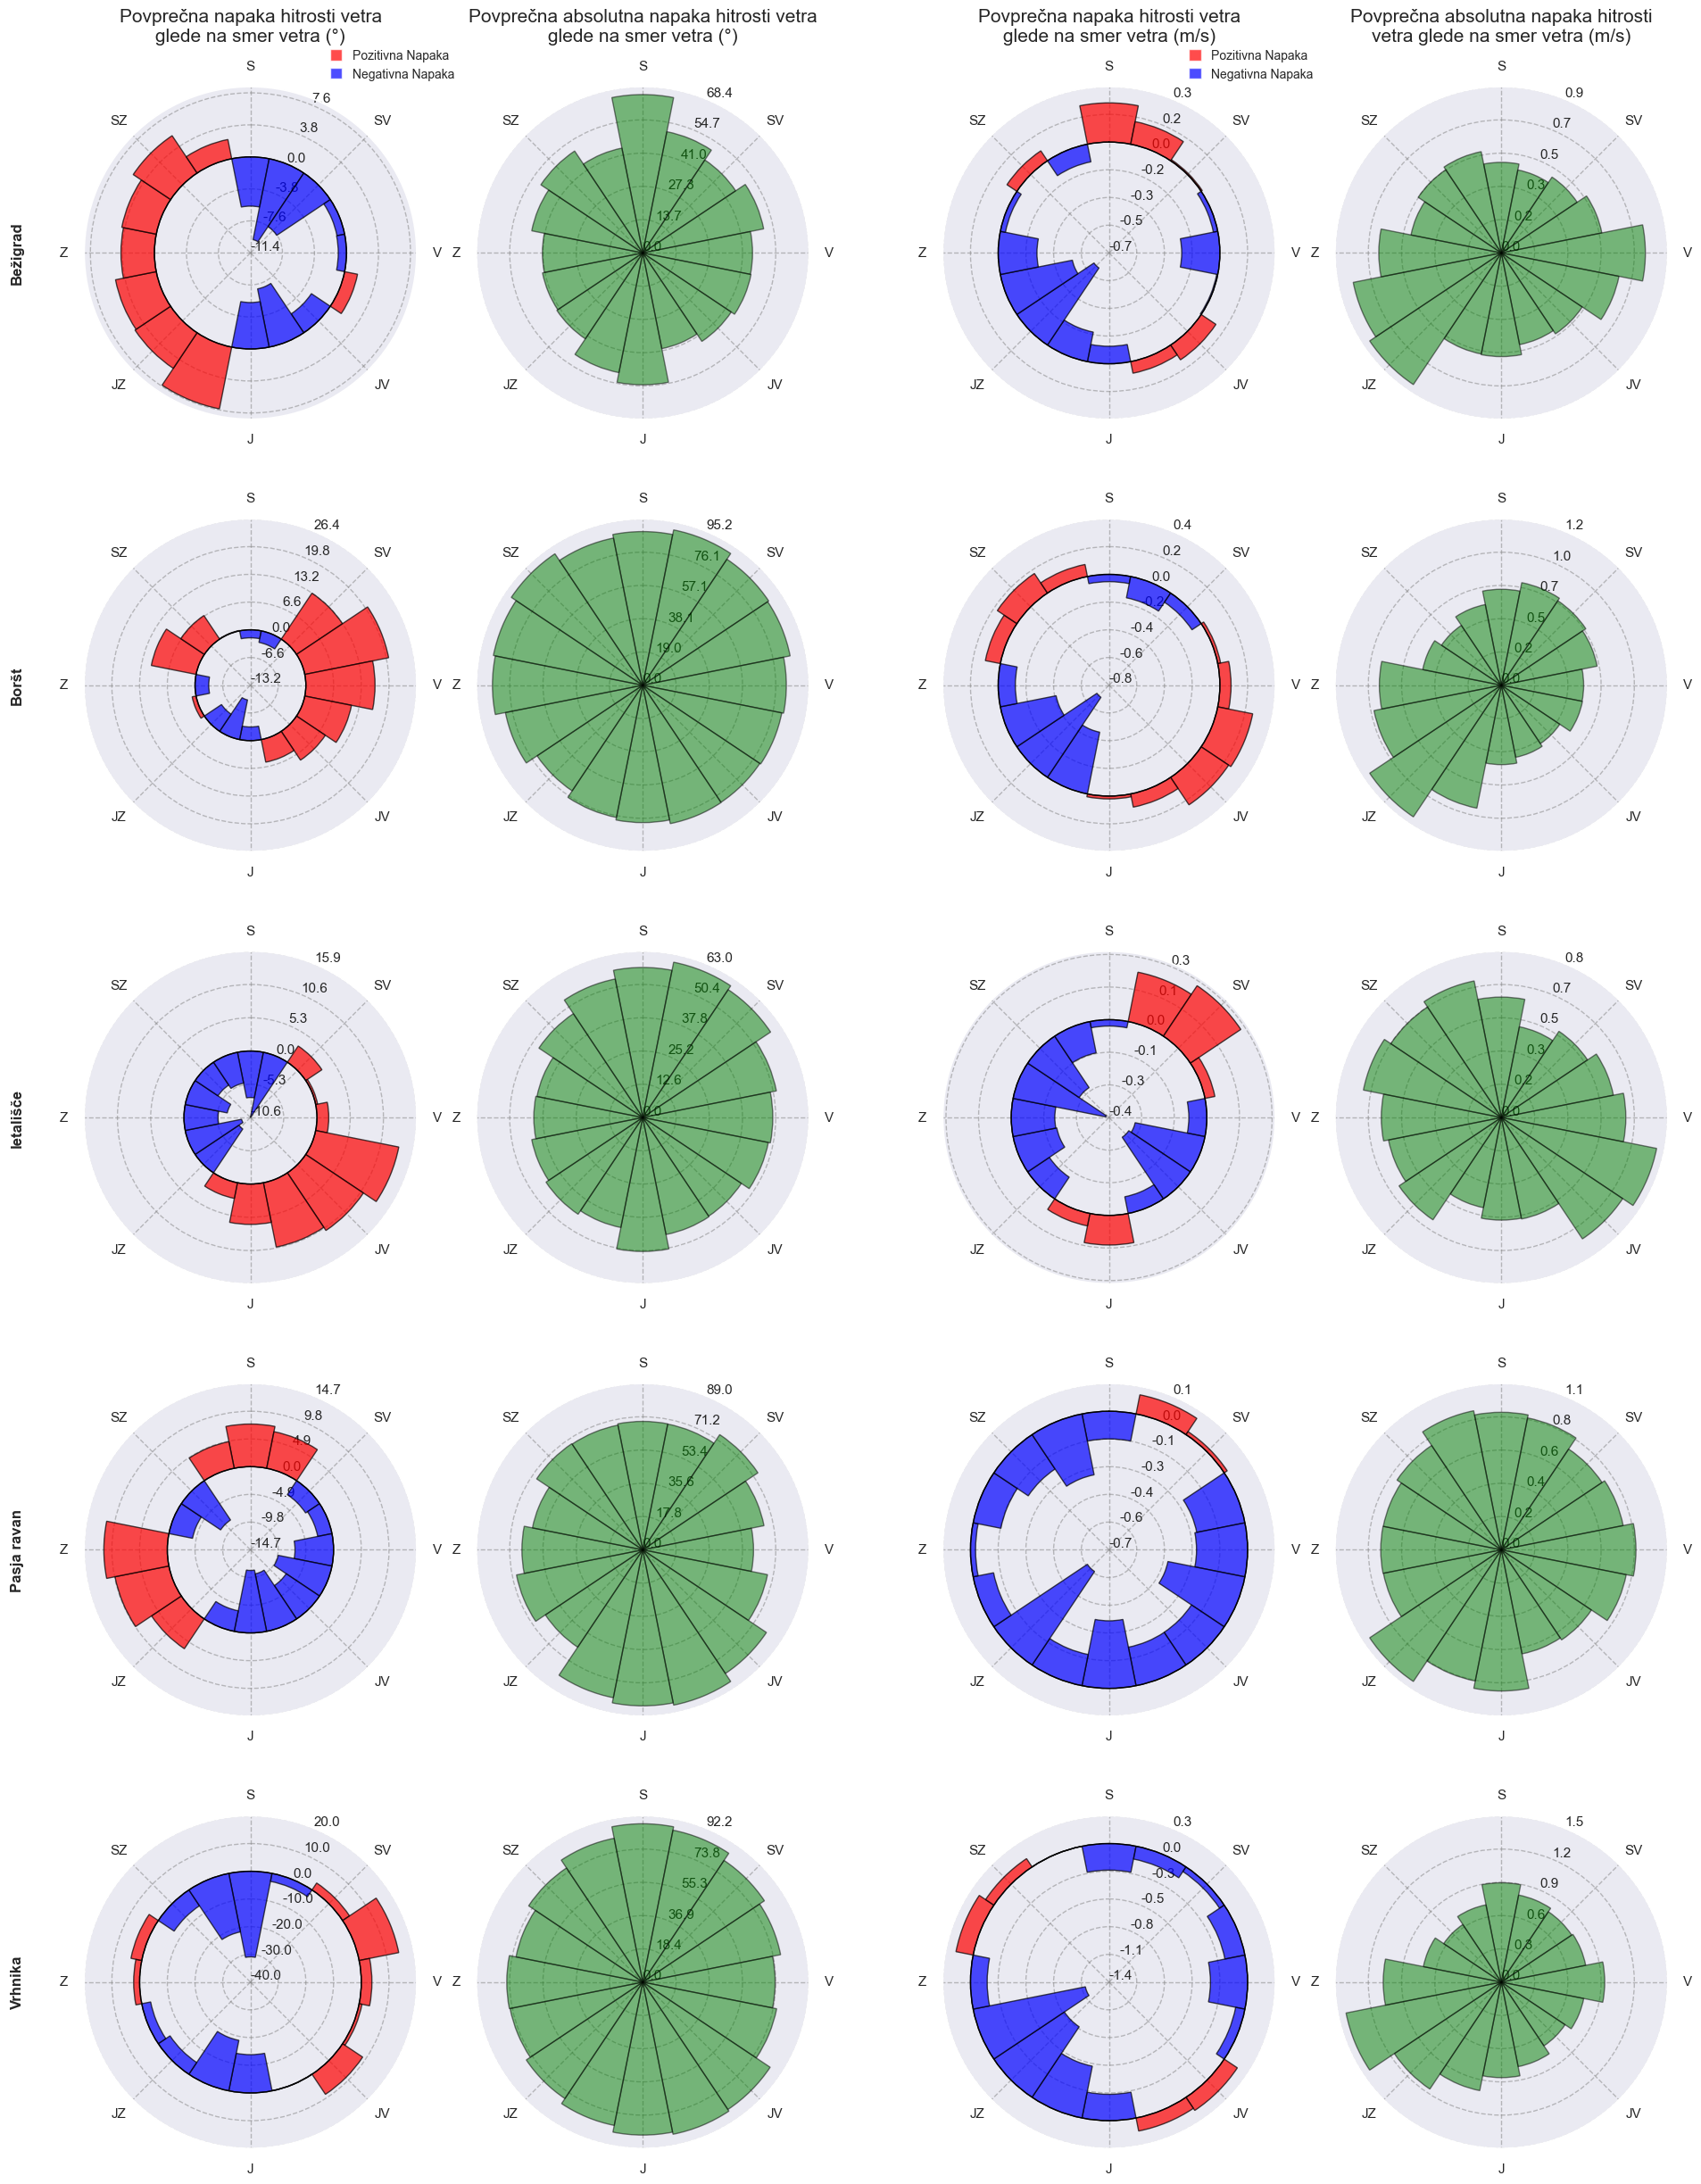

In [10]:
compare_wind_plots_for_stations(df_both, [s for s in stations])

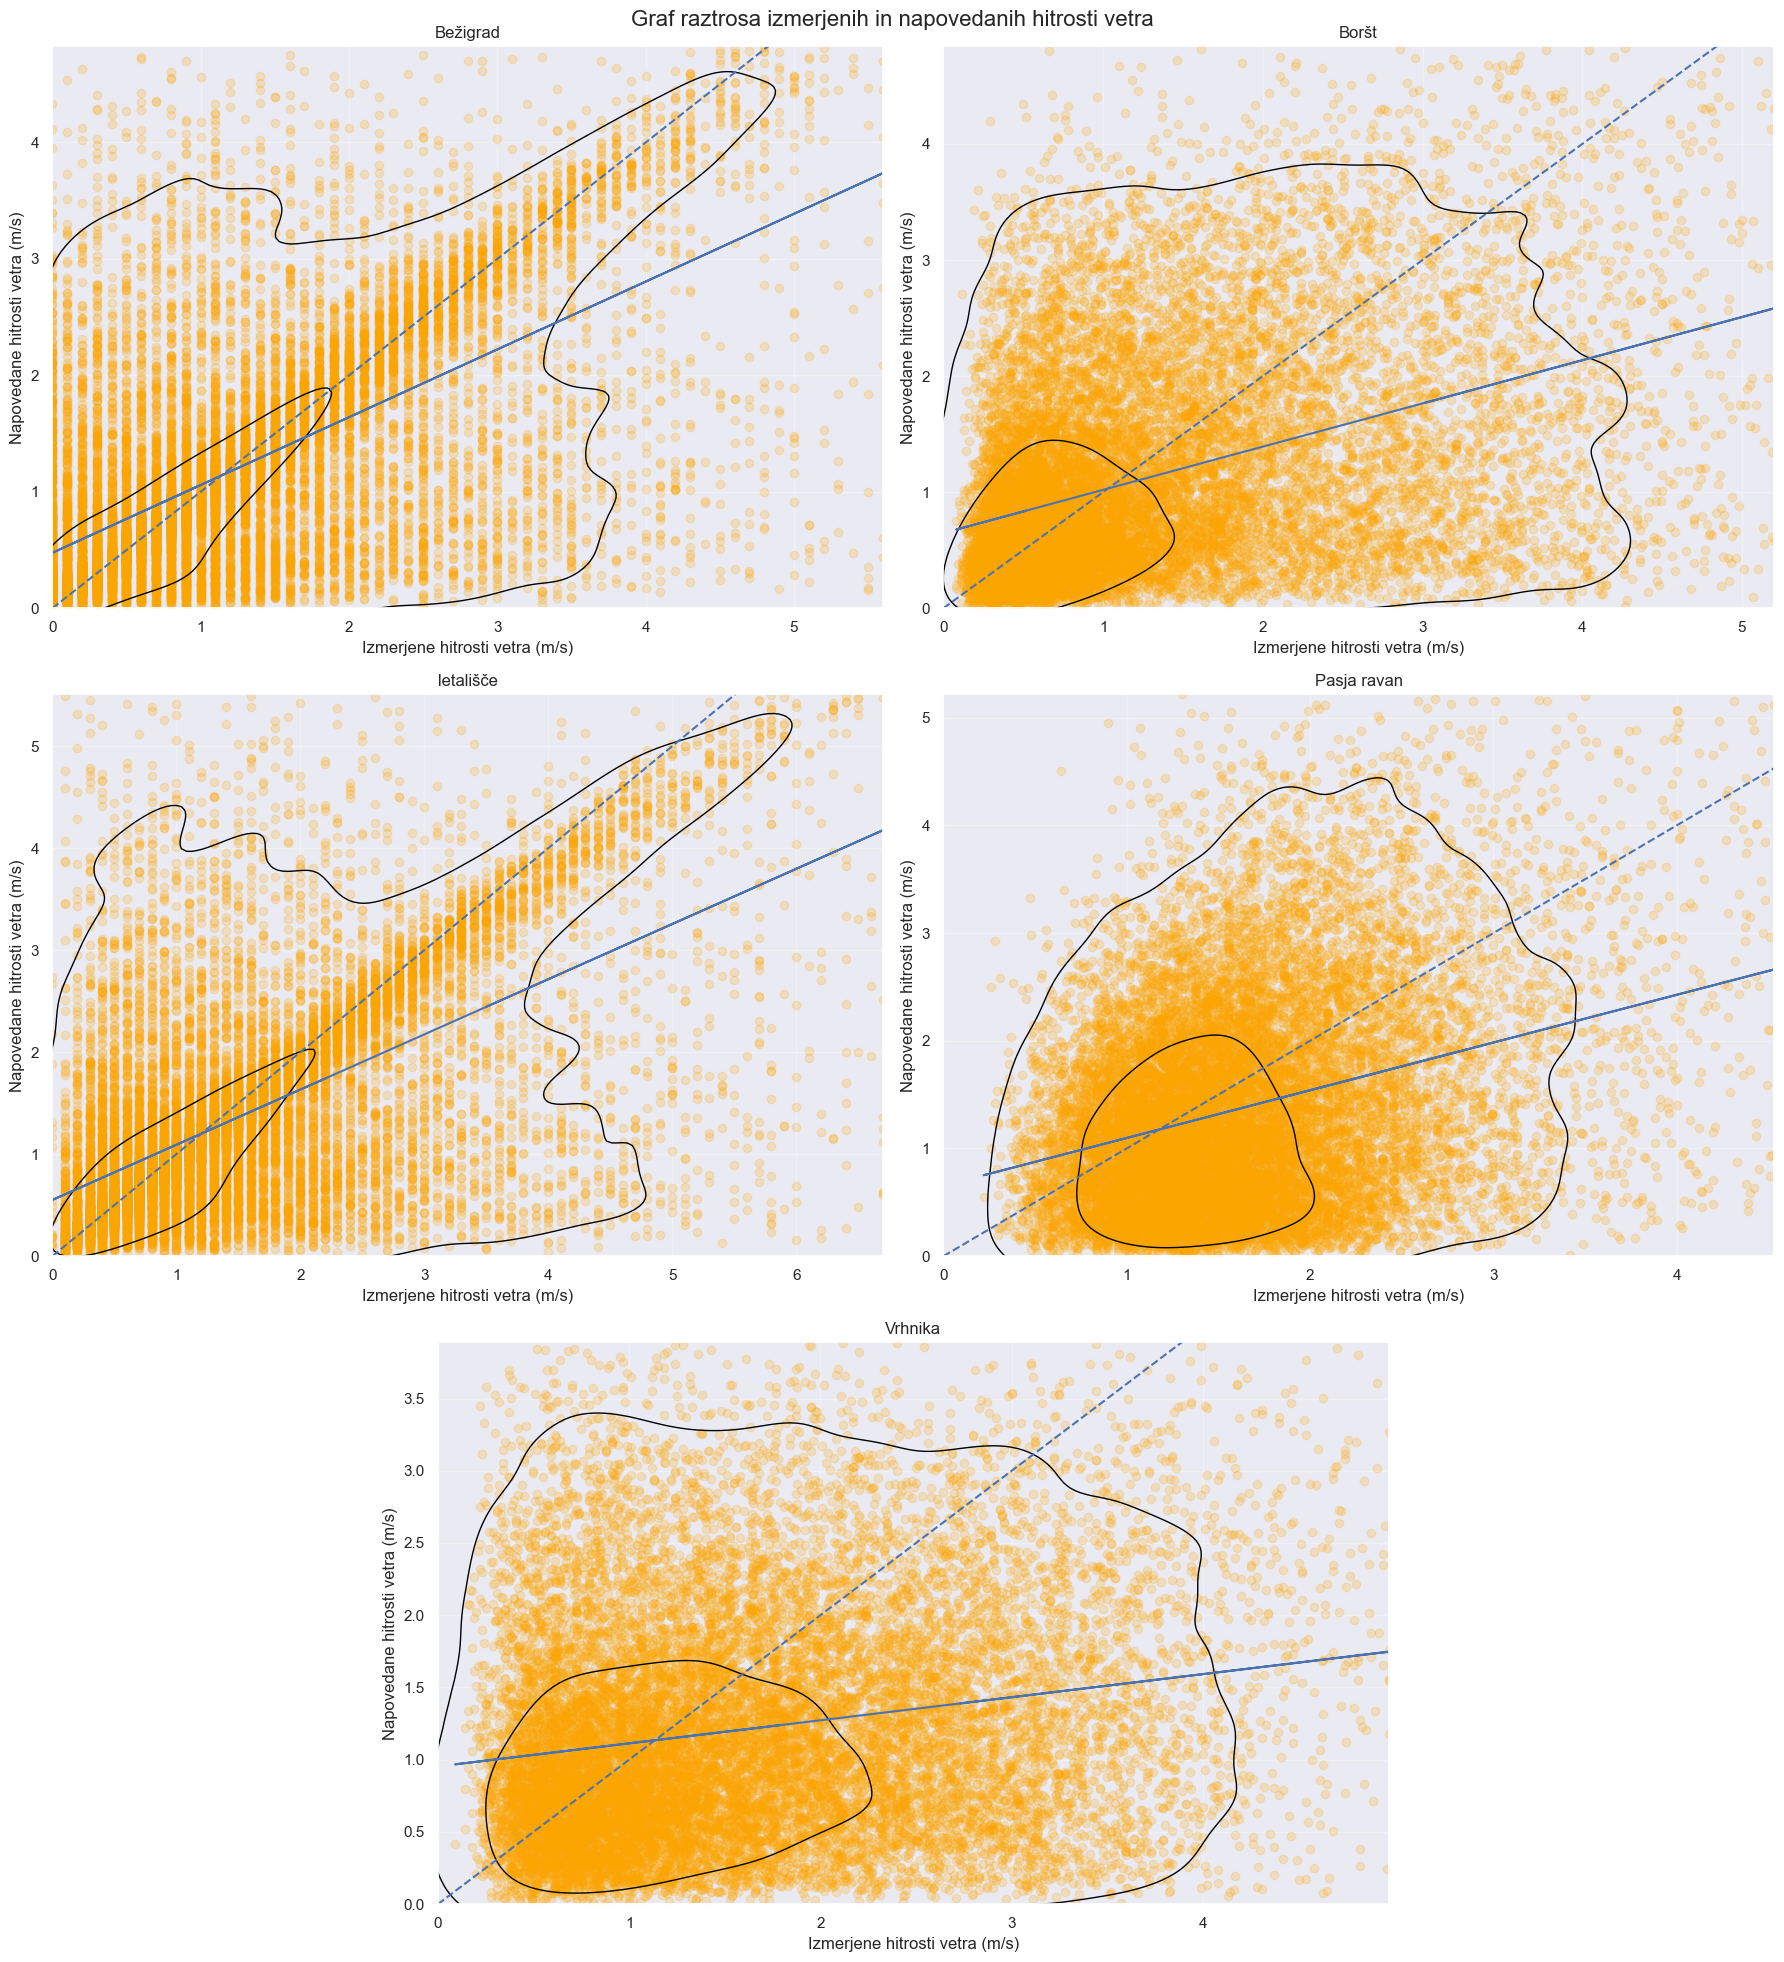

In [11]:
plot_wind_speed_comparison(df_both, stations, names)

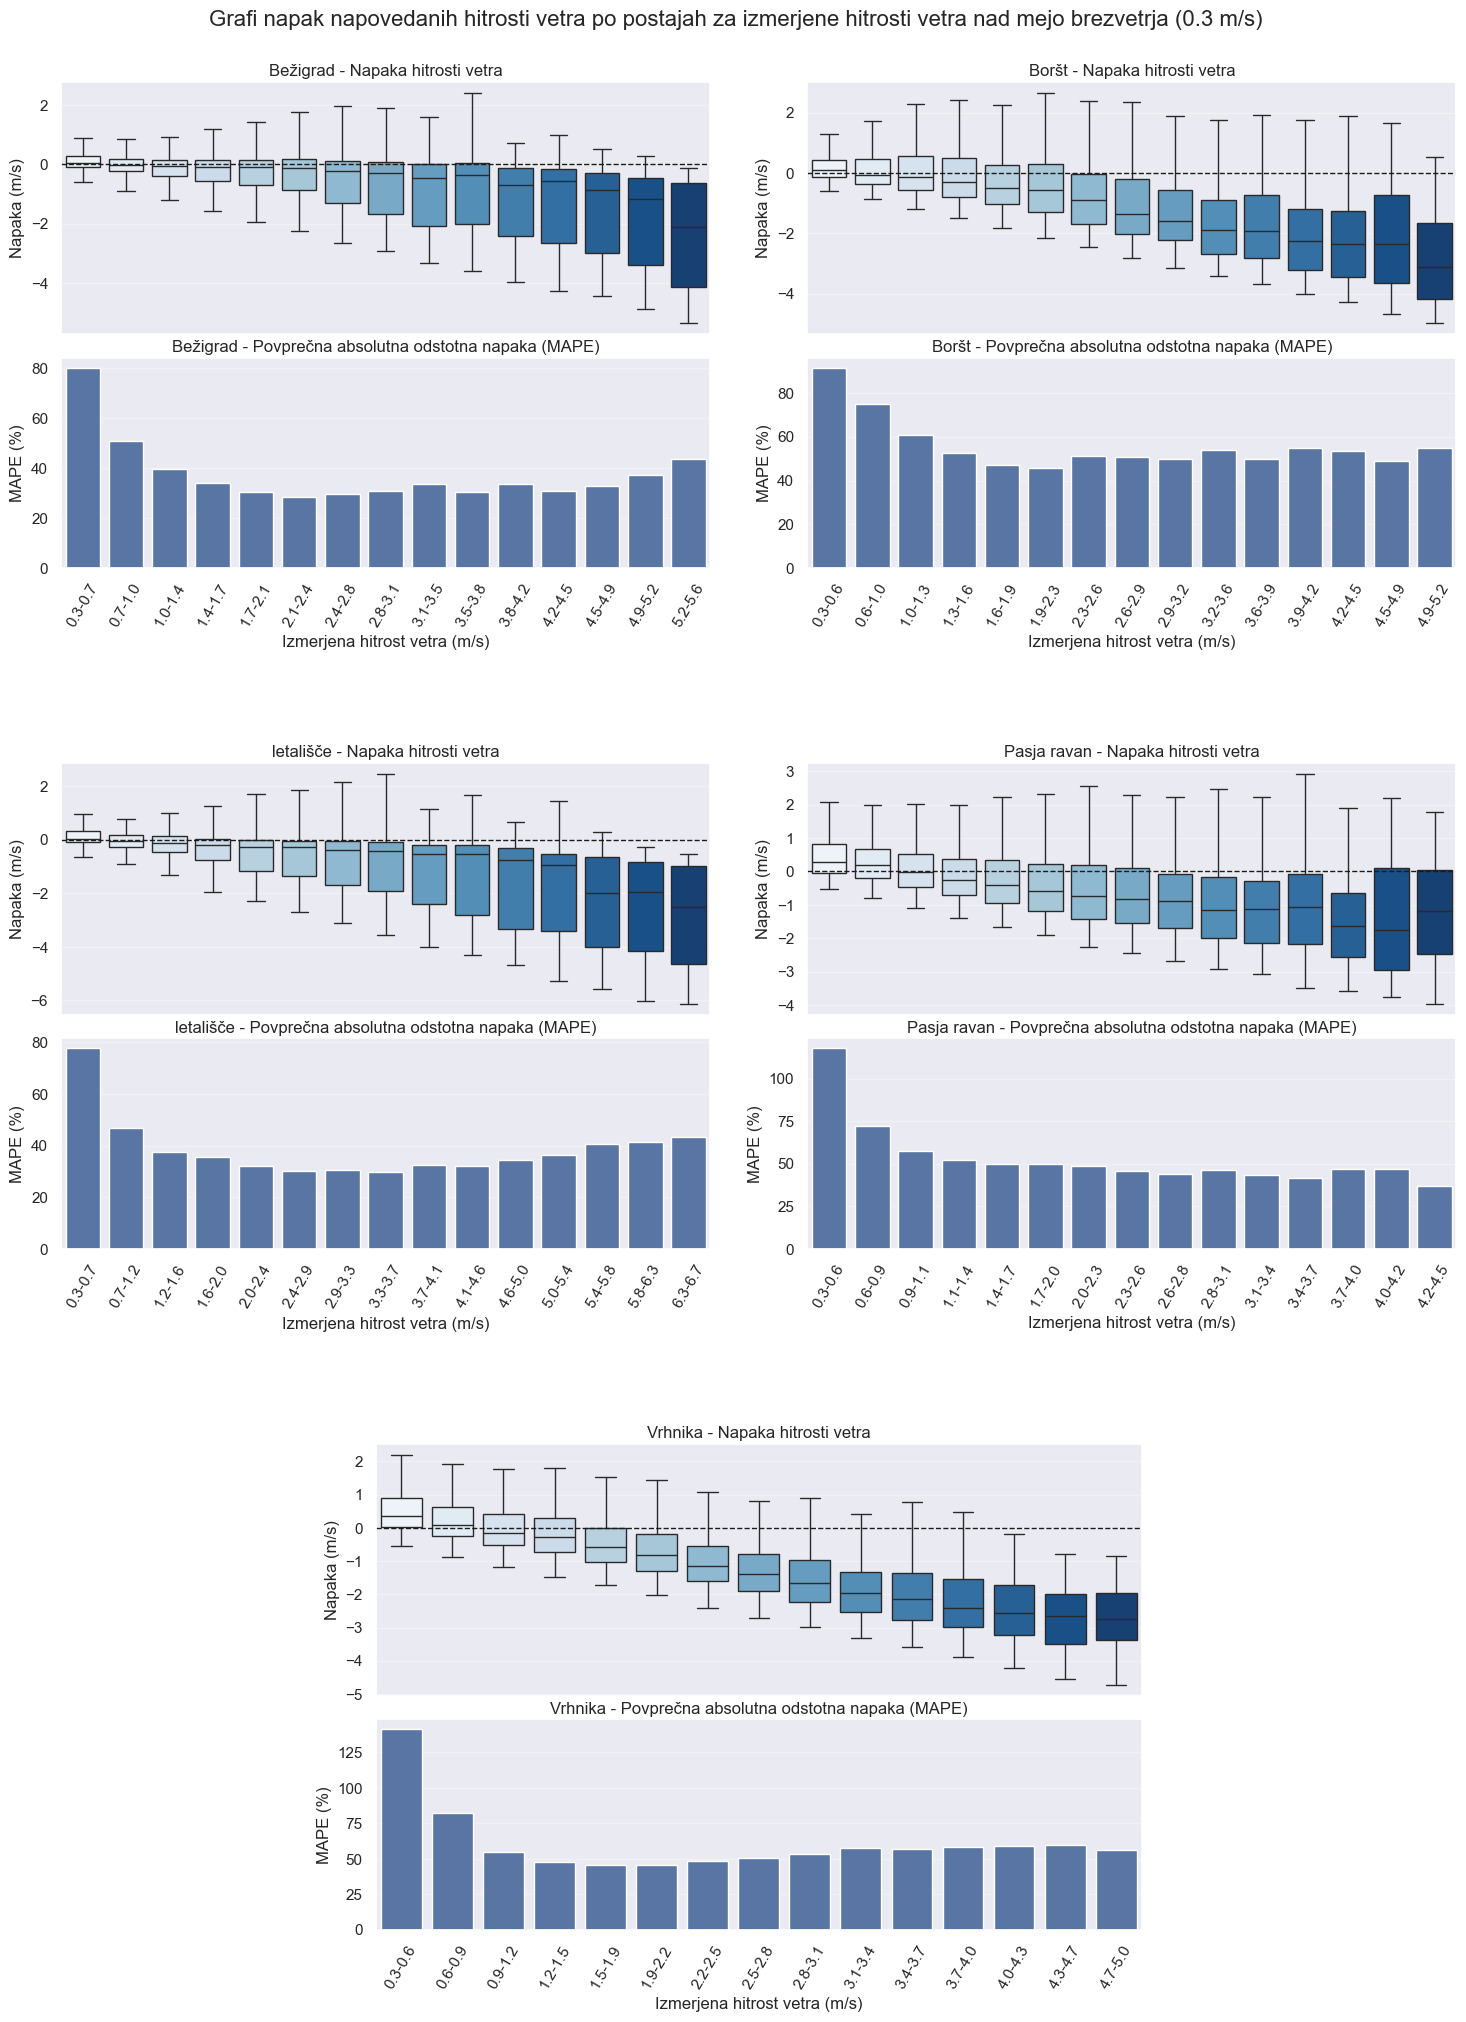

In [12]:
plot_wind_errors_all_stations(df=df_both, stations=[s for s in stations], names=names, num_bins=15, min_wspeed=0.3)

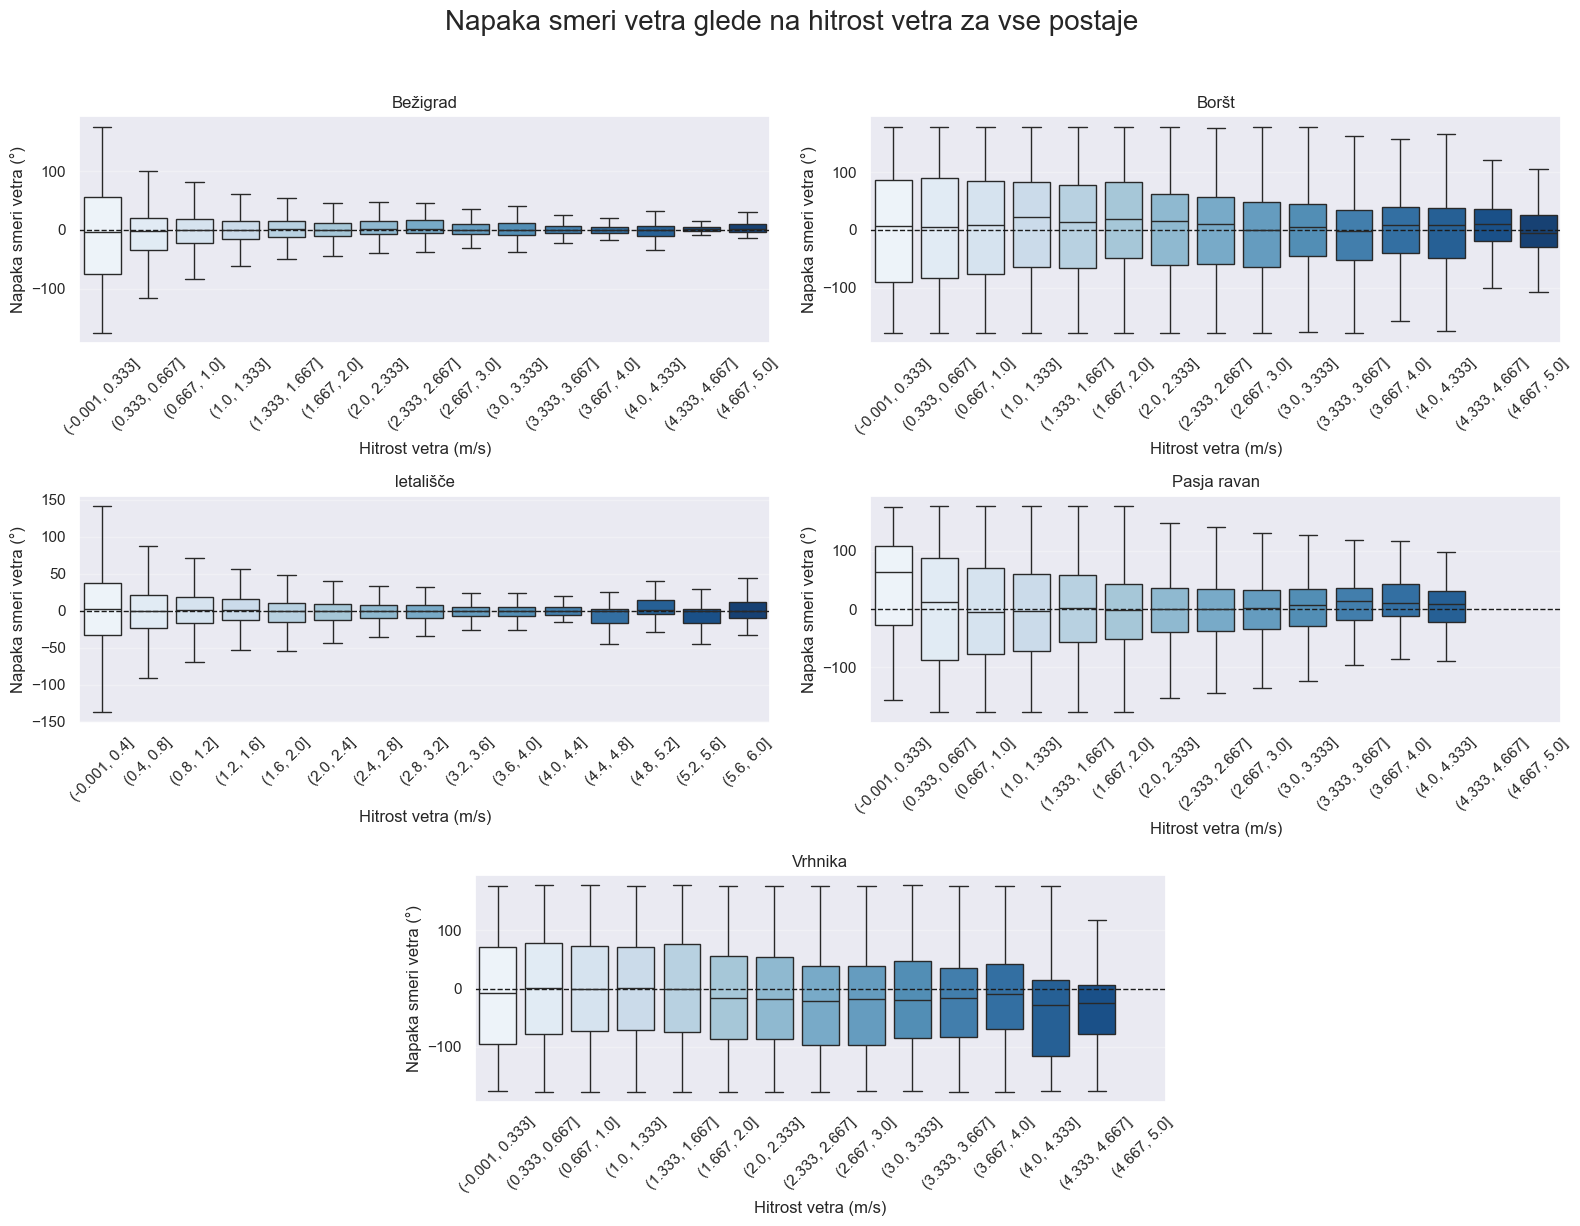

In [13]:
plot_wdir_error_by_wspeed_all_stations(df_both, stations, num_bins=15, names=names)

<Figure size 1400x1500 with 0 Axes>

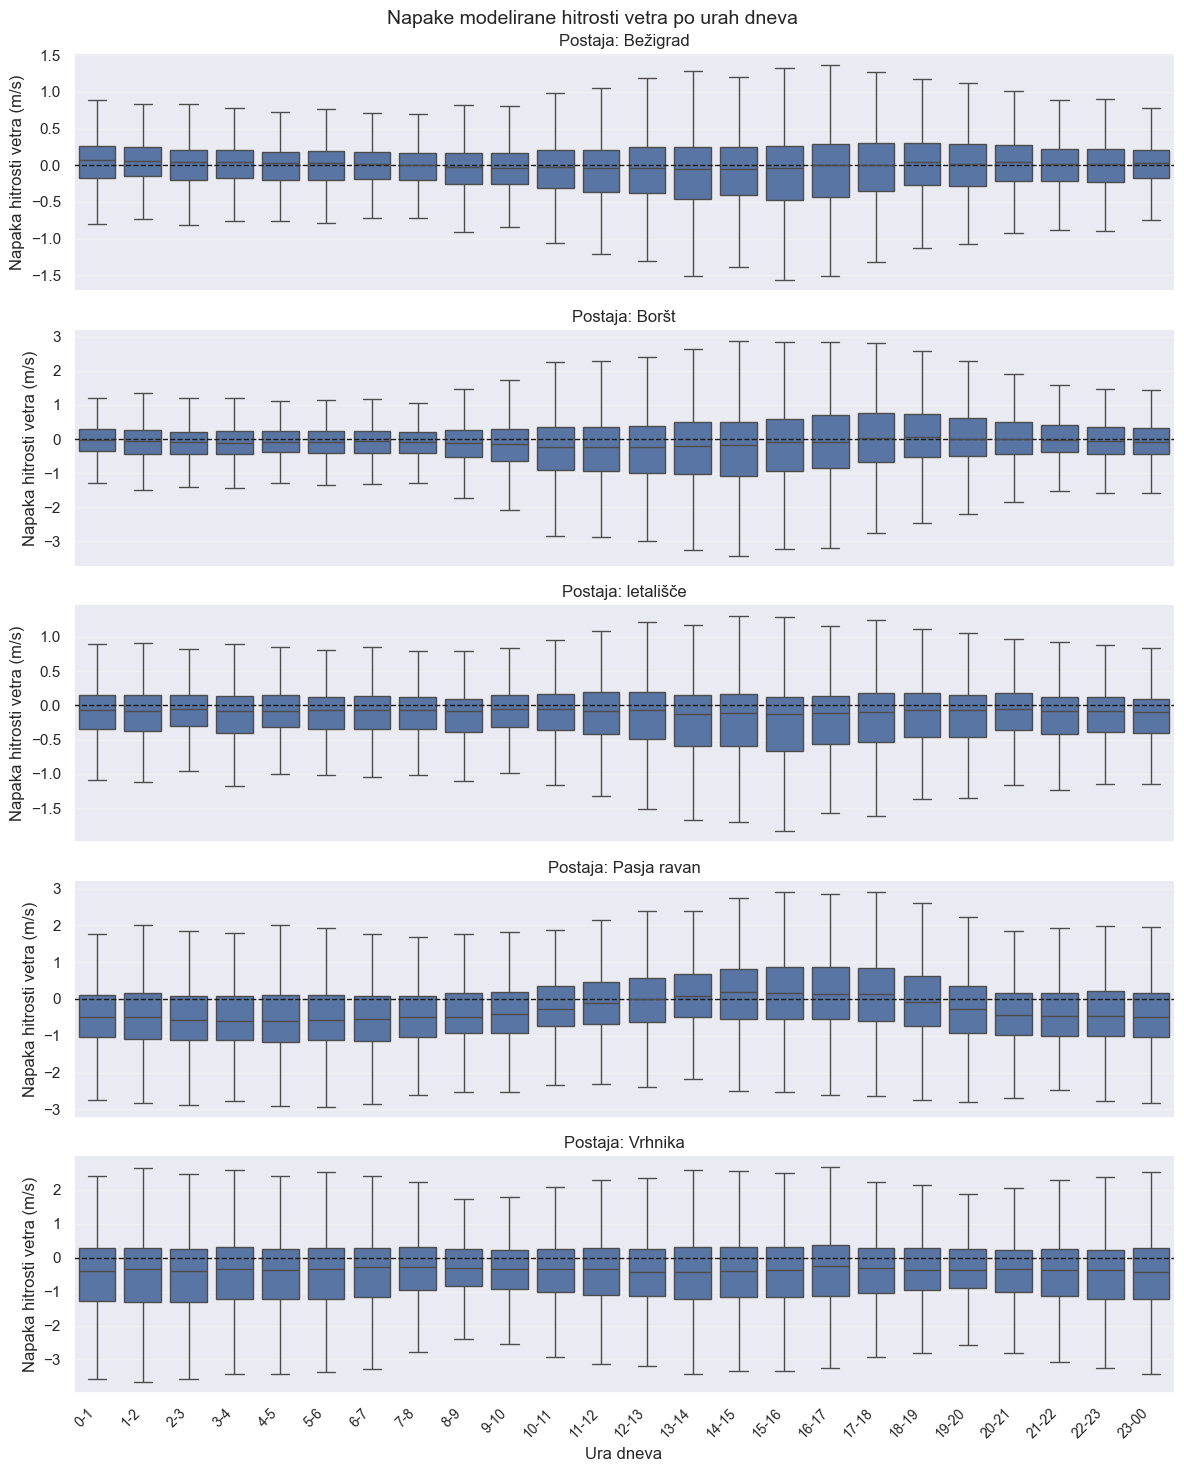

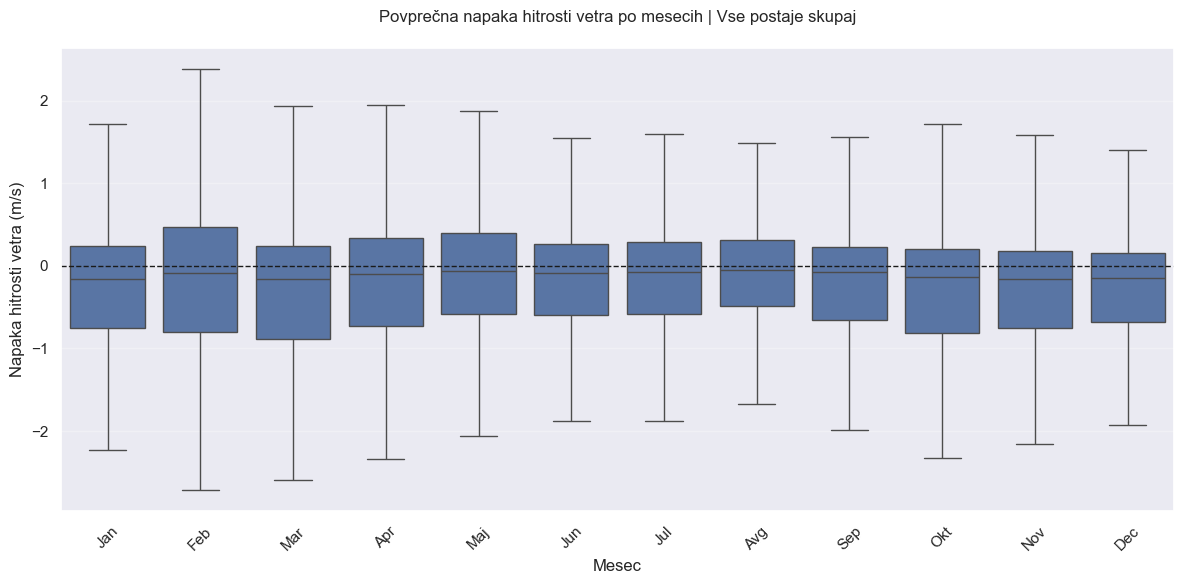

In [14]:
plot_wind_speed_error_by_hour_multistation(df_both, [s for s in stations], names=names)

plot_wind_speed_error_by_month_all_stations(df_both, [s for s in stations], names)

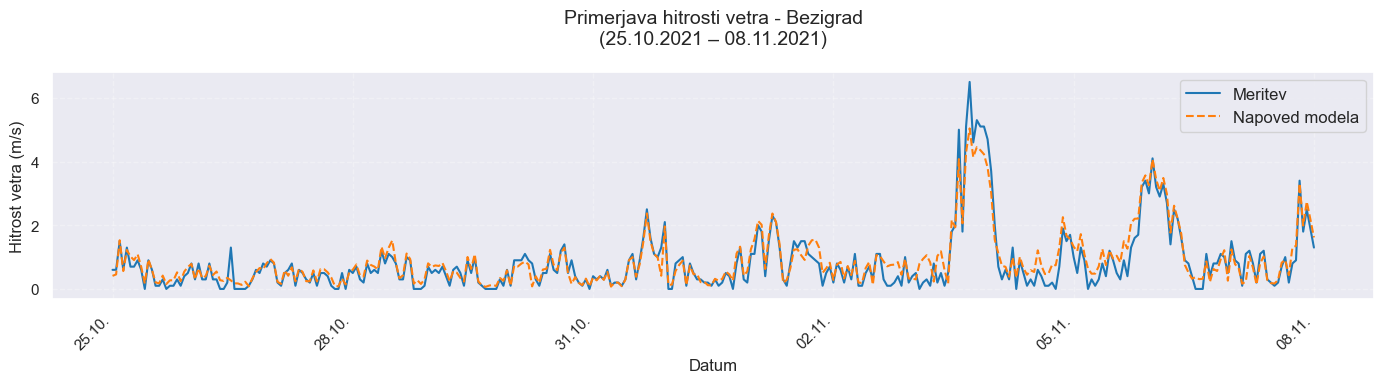

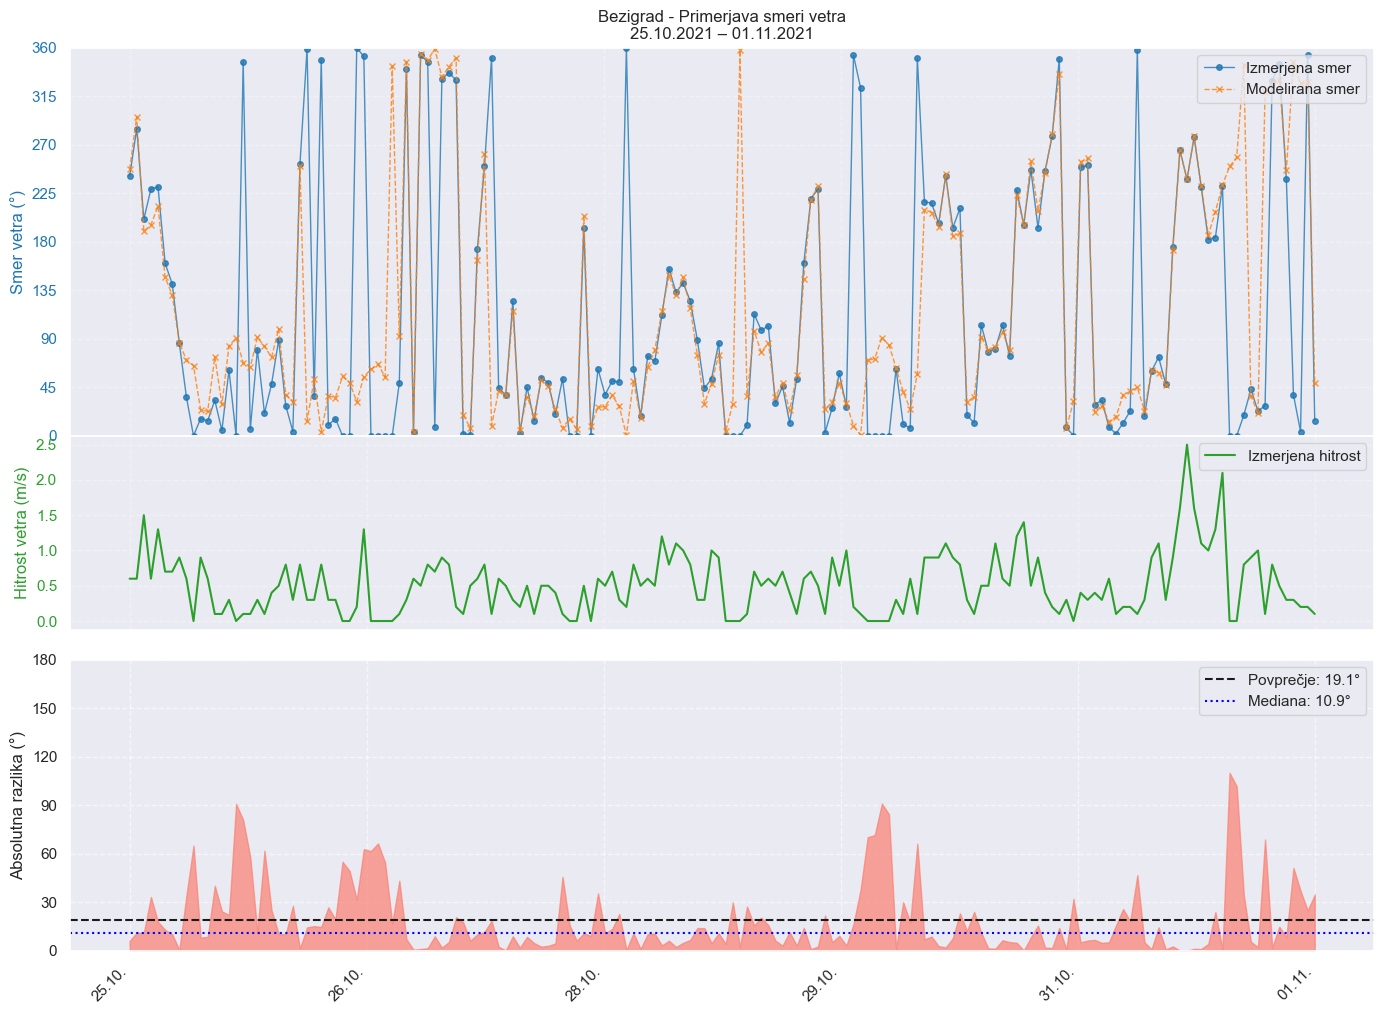

In [16]:
plot_wind_comparison(random.choice([df_2021, df_2023]), "bezigrad")